In [2]:
import json
import pandas as pd
import h5py
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import model_from_json
import keras
from tensorflow.keras.layers import Dense, GRU
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import plot_model

# load model
json = 'model_rnn_GRU.120_Dense.5010_LSTMKernelInit.VarianceScaling_DenseKernelInit.lecun_uniformKRl1.0_KRl2.0_recAct.sigmoid_arch.json'
with open(json, 'r') as json_file:
    load = json_file.read()
model = model_from_json(load)

# load weights
weights = 'model_rnn_GRU.120_Dense.5010_LSTMKernelInit.VarianceScaling_DenseKernelInit.lecun_uniformKRl1.0_KRl2.0_recAct.sigmoid_weights.h5'
model.load_weights(weights)

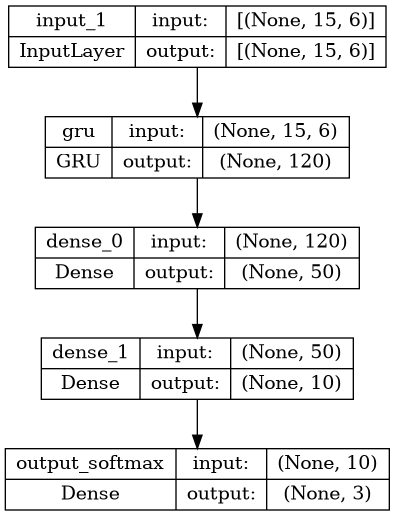

In [3]:
plot_model(model, show_shapes=True, show_layer_names=True)

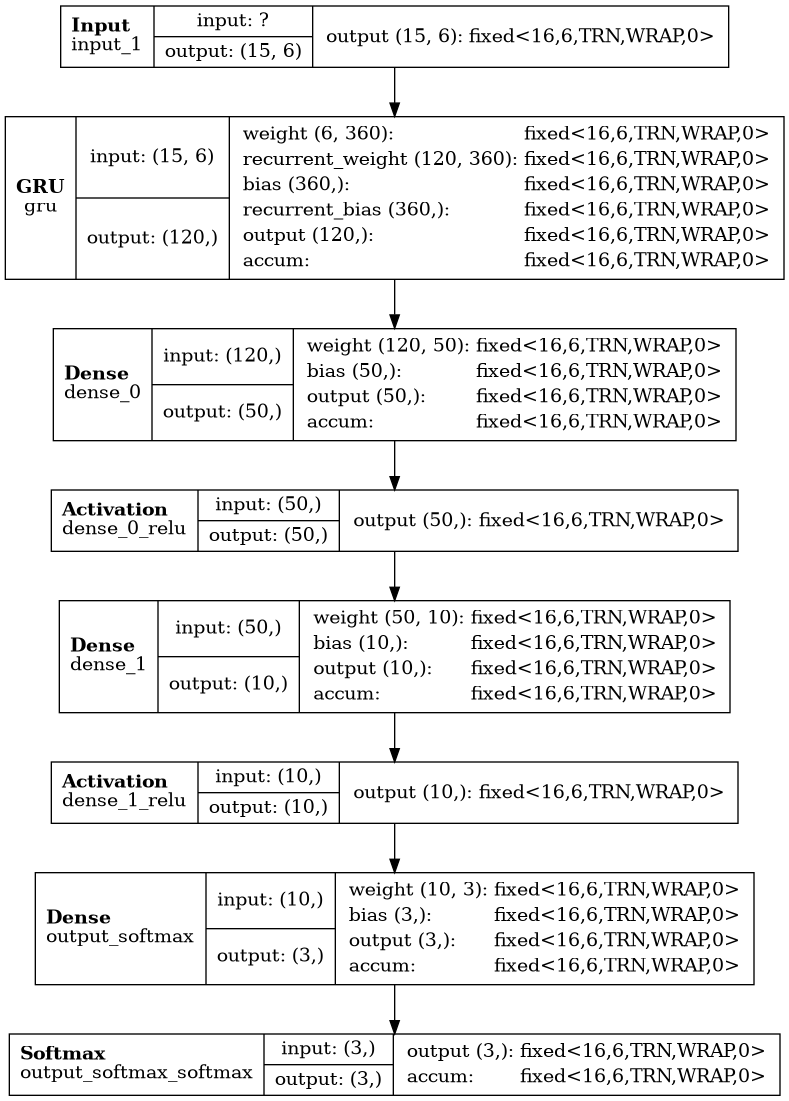

In [5]:
# create hls4ml model
import hls4ml

config = hls4ml.utils.config_from_keras_model(model, granularity='model')

hls_model = hls4ml.converters.convert_from_keras_model(
    model, hls_config=config, backend='Vivado', output_dir='ftag_hls4ml_model', part='xc7vx690tffg1761-2'
)

hls4ml.utils.plot_model(hls_model, show_shapes=True, show_precision=True, to_file=None)

In [6]:
hls_model.compile()